# Initialisation notebook lié au Projet 9 

In [22]:
import sys
from pathlib import Path
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow :", tf.__version__)
print("GPU :", "Yes" if tf.config.list_physical_devices('GPU') else "No")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

TRAIN_IMAGES = DATA_PROCESSED / "images" / "train"
VAL_IMAGES   = DATA_PROCESSED / "images" / "val"
TEST_IMAGES  = DATA_PROCESSED / "images" / "test"

TRAIN_MASKS = DATA_PROCESSED / "masks" / "train"
VAL_MASKS   = DATA_PROCESSED / "masks" / "val"
TEST_MASKS  = DATA_PROCESSED / "masks" / "test"

assert TRAIN_IMAGES.exists(), "Images train manquantes"
assert TRAIN_MASKS.exists(),  "Masks train manquants"

print("Project root :", PROJECT_ROOT)
print("Train images :", len(list(TRAIN_IMAGES.glob("*.png"))))
print("Train masks  :", len(list(TRAIN_MASKS.glob("*.png"))))

sys.path.append(str(PROJECT_ROOT / "src"))

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = False

print("Init notebook : OK")


TensorFlow : 2.16.1
GPU : No
Project root : c:\Users\vicau\P8OC
Train images : 580
Train masks  : 580
Init notebook : OK


## Import du générateur

In [23]:
import inspect
from dataloader import CityscapesSequence # type: ignore

print("CityscapesSequence signature:")
print(inspect.signature(CityscapesSequence))


CityscapesSequence signature:
(image_paths, mask_paths, batch_size=4, target_size=(256, 512), augment=False, n_classes=8, shuffle=True)


## Instanciation du generateur 

In [24]:
from pathlib import Path
import tensorflow as tf

# ===========================
# DataGenerators (FULL + anti-corruption) + switch debug
# ===========================

DATA_MODE = "full"   # "full" ou "test_only"

BATCH_SIZE = 4
IMG_HEIGHT = 256
IMG_WIDTH  = 512
N_CLASSES  = 8

def list_pngs(folder: Path):
    files = sorted(folder.glob("*.png"))
    return files

def filter_readable_pairs(img_paths, mask_paths):
    """Filtre les paires (image, mask) illisibles sans casser l'alignement zip()."""
    ok_imgs, ok_masks = [], []
    bad = 0
    for im, mk in zip(img_paths, mask_paths):
        try:
            _ = tf.io.decode_png(tf.io.read_file(str(im)), channels=3)
            _ = tf.io.decode_png(tf.io.read_file(str(mk)), channels=1)
            ok_imgs.append(im)
            ok_masks.append(mk)
        except Exception:
            bad += 1
    return ok_imgs, ok_masks, bad

# ---------------------------
# 1) Listes de fichiers
# ---------------------------
if DATA_MODE == "test_only":
    test_image_paths = list_pngs(TEST_IMAGES)
    test_mask_paths  = list_pngs(TEST_MASKS)

    print("TEST samples :", len(test_image_paths), "| masks:", len(test_mask_paths))
    print("Ex test image:", test_image_paths[0].name if test_image_paths else "EMPTY")
    print("Ex test mask :", test_mask_paths[0].name if test_mask_paths else "EMPTY")
    assert len(test_image_paths) == len(test_mask_paths), "Test: nb images != nb masks"

    # Anti-corruption (sur TEST)
    test_image_paths, test_mask_paths, bad_test = filter_readable_pairs(test_image_paths, test_mask_paths)
    print(f"Filtered corrupted pairs (TEST): {bad_test}")
    print("TEST after filter:", len(test_image_paths), "| masks:", len(test_mask_paths))

    # On réutilise TEST pour train/val/test
    train_image_paths = test_image_paths
    val_image_paths   = test_image_paths
    train_mask_paths  = test_mask_paths
    val_mask_paths    = test_mask_paths

else:  # full
    train_image_paths = list_pngs(TRAIN_IMAGES)
    val_image_paths   = list_pngs(VAL_IMAGES)
    test_image_paths  = list_pngs(TEST_IMAGES)

    train_mask_paths  = list_pngs(TRAIN_MASKS)
    val_mask_paths    = list_pngs(VAL_MASKS)
    test_mask_paths   = list_pngs(TEST_MASKS)

    print("Train samples :", len(train_image_paths), "| masks:", len(train_mask_paths))
    print("Val samples   :", len(val_image_paths),   "| masks:", len(val_mask_paths))
    print("Test samples  :", len(test_image_paths),  "| masks:", len(test_mask_paths))

    assert len(train_image_paths) == len(train_mask_paths), "Train: nb images != nb masks"
    assert len(val_image_paths)   == len(val_mask_paths),   "Val: nb images != nb masks"
    assert len(test_image_paths)  == len(test_mask_paths),  "Test: nb images != nb masks"

    # Anti-corruption (train/val/test)
    train_image_paths, train_mask_paths, bad_train = filter_readable_pairs(train_image_paths, train_mask_paths)
    val_image_paths,   val_mask_paths,   bad_val   = filter_readable_pairs(val_image_paths,   val_mask_paths)
    test_image_paths,  test_mask_paths,  bad_test  = filter_readable_pairs(test_image_paths,  test_mask_paths)

    print(f"Filtered corrupted pairs -> Train:{bad_train} | Val:{bad_val} | Test:{bad_test}")
    print("After filter:",
          "Train", len(train_image_paths),
          "| Val", len(val_image_paths),
          "| Test", len(test_image_paths))

# ---------------------------
# 2) Générateurs
# ---------------------------
train_gen = CityscapesSequence(
    image_paths=train_image_paths,
    mask_paths=train_mask_paths,
    batch_size=BATCH_SIZE,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    augment=True,
    n_classes=N_CLASSES,
    shuffle=True
)

val_gen = CityscapesSequence(
    image_paths=val_image_paths,
    mask_paths=val_mask_paths,
    batch_size=BATCH_SIZE,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    augment=False,
    n_classes=N_CLASSES,
    shuffle=False
)

test_gen = CityscapesSequence(
    image_paths=test_image_paths,
    mask_paths=test_mask_paths,
    batch_size=BATCH_SIZE,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    augment=False,
    n_classes=N_CLASSES,
    shuffle=False
)

print("Train batches :", len(train_gen))
print("Val batches   :", len(val_gen))
print("Test batches  :", len(test_gen))
print(f"Bloc DataGenerators : OK ({DATA_MODE})")


Train samples : 580 | masks: 580
Val samples   : 262 | masks: 262
Test samples  : 10 | masks: 10
Filtered corrupted pairs -> Train:0 | Val:0 | Test:0
After filter: Train 580 | Val 262 | Test 10
Train batches : 145
Val batches   : 65
Test batches  : 2
Bloc DataGenerators : OK (full)


c:\Users\vicau\P8OC\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Check de qualité 

x shape: (4, 256, 512, 3) | dtype: float32 | min/max: 0.0313725508749485 1.0
y shape: (4, 256, 512, 8) | dtype: float32
Mask one-hot check (sum per pixel) -> min/max: 1.0 1.0
Classes présentes (test batch 0): [0 1 2 3 4 5 6 7]


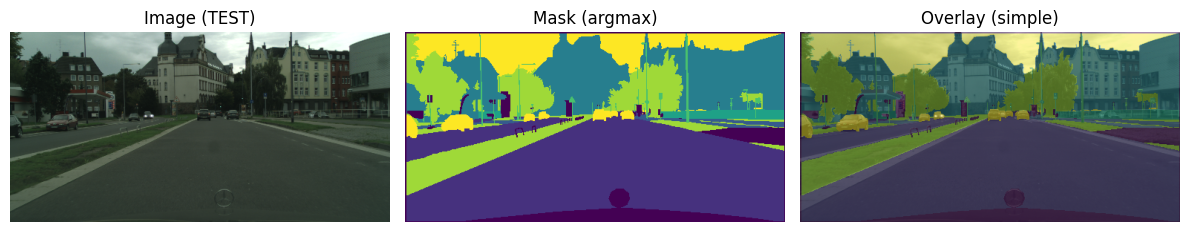

In [25]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Récupération d'un batch du générateur de test
# ------------------------------------------------------------
x, y = test_gen[0]


# ------------------------------------------------------------
# Vérification des images (x)
# ------------------------------------------------------------
print(
    "x shape:", x.shape,
    "| dtype:", x.dtype,
    "| min/max:", float(x.min()), float(x.max())
)


# ------------------------------------------------------------
# Vérification des masques (y)
# ------------------------------------------------------------
print(
    "y shape:", y.shape,
    "| dtype:", y.dtype
)


# ------------------------------------------------------------
# Vérification du format one-hot :
# La somme sur l'axe des classes doit être égale à 1 par pixel
# ------------------------------------------------------------
sum_per_pixel = np.sum(y, axis=-1)
print(
    "Mask one-hot check (sum per pixel) -> min/max:",
    float(sum_per_pixel.min()),
    float(sum_per_pixel.max())
)


# ------------------------------------------------------------
# Vérification des classes réellement présentes dans le batch
# ------------------------------------------------------------
y_classes = np.argmax(y, axis=-1)
print("Classes présentes (test batch 0):", np.unique(y_classes))


# ------------------------------------------------------------
# Visualisation rapide d'un échantillon
# ------------------------------------------------------------
idx = 0  # index de l'image affichée

img = x[idx]
mask = y_classes[idx]

plt.figure(figsize=(12, 4))


# Image brute
plt.subplot(1, 3, 1)
plt.title("Image (TEST)")
plt.imshow(img.astype(np.float32))
plt.axis("off")


# Masque après argmax
plt.subplot(1, 3, 2)
plt.title("Mask (argmax)")
plt.imshow(mask, vmin=0, vmax=N_CLASSES - 1)
plt.axis("off")


# Superposition image + masque
plt.subplot(1, 3, 3)
plt.title("Overlay (simple)")
plt.imshow(img.astype(np.float32))
plt.imshow(mask, alpha=0.45, vmin=0, vmax=N_CLASSES - 1)
plt.axis("off")

plt.tight_layout()
plt.show()


# Import des metriques 

In [26]:
import tensorflow as tf
import numpy as np
from pathlib import Path

from metrics import dice_loss, iou_metric, dice_coef, pixel_accuracy # type: ignore

def eval_model(model, gen, name="model"):
    res = model.evaluate(gen, verbose=1, return_dict=True)
    print(f"\n✅ {name} results:")
    for k, v in res.items():
        print(f" - {k}: {v:.4f}")
    return res

print("Metrics import : OK")


Metrics import : OK


# baseline VGG16 (modèle actuel)

In [28]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

# Permet "import src...." depuis le notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.unet_vgg16 import unet_vgg16

baseline = unet_vgg16(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=N_CLASSES)

baseline_val = baseline.evaluate(val_gen, verbose=0, return_dict=True)

print("\n✅ Baseline VGG16 results (VAL, cold):")
for k in ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]:
    if k in baseline_val:
        print(f" - {k}: {baseline_val[k]:.4f}")


c:\Users\vicau\P8OC\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



✅ Baseline VGG16 results (VAL, cold):
 - loss: 0.9356
 - dice_coef: 0.0644
 - iou_metric: 0.0158
 - pixel_accuracy: 0.0481


## Entrainement VGG16 (modele de prod)

In [29]:
import warnings
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # type: ignore

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

EPOCHS_VGG16 = 7

callbacks = [
    EarlyStopping(monitor="val_loss", mode="min", patience=8, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.3, patience=4, min_lr=1e-6, verbose=0),
]

print(f"\n===== Training baseline VGG16 (epochs={EPOCHS_VGG16}) =====")

baseline.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_VGG16,
    callbacks=callbacks,
    verbose=1,
)

baseline_val_after = baseline.evaluate(val_gen, verbose=0, return_dict=True)

print("\n✅ Baseline VGG16 results (VAL, after training):")
for k in ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]:
    if k in baseline_val_after:
        print(f" - {k}: {baseline_val_after[k]:.4f}")



===== Training baseline VGG16 (epochs=7) =====


c:\Users\vicau\P8OC\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - dice_coef: 0.4022 - iou_metric: 0.1165 - loss: 0.5978 - pixel_accuracy: 0.4030 - val_dice_coef: 0.5467 - val_iou_metric: 0.1846 - val_loss: 0.4533 - val_pixel_accuracy: 0.5472 - learning_rate: 1.0000e-04
Epoch 2/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - dice_coef: 0.5477 - iou_metric: 0.1910 - loss: 0.4523 - pixel_accuracy: 0.5482 - val_dice_coef: 0.5454 - val_iou_metric: 0.1966 - val_loss: 0.4546 - val_pixel_accuracy: 0.5463 - learning_rate: 1.0000e-04
Epoch 3/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - dice_coef: 0.5602 - iou_metric: 0.2023 - loss: 0.4398 - pixel_accuracy: 0.5607 - val_dice_coef: 0.5743 - val_iou_metric: 0.2064 - val_loss: 0.4257 - val_pixel_accuracy: 0.5748 - learning_rate: 1.0000e-04
Epoch 4/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - dice_coef: 0.5664 - iou_metric: 0.2016 - loss: 0.4336 - pixel_accuracy: 0.5668 - val_dice_coef: 0.5768 - val_iou_metric: 0.2166 - val_loss: 0.4232 - val_pixel_accuracy: 0.5

# Baseline EffNetV2B0 (nouveau modele)

In [30]:
import sys
import warnings
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models  # type: ignore

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

# Pour pouvoir faire "from src...."
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.metrics import dice_loss, iou_metric, dice_coef, pixel_accuracy

def unet_effnetv2b0(input_shape=(256, 512, 3), num_classes=8):
    inputs = layers.Input(shape=input_shape)

    x = layers.Rescaling(255.0)(inputs)

    encoder = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        include_preprocessing=True,
    )

    # Comme P8 : backbone gelé
    for layer in encoder.layers:
        layer.trainable = False

    # Skips auto (2,4,8,16) en fonction de la résolution
    skips = {}
    in_h = input_shape[0]
    for layer in encoder.layers:
        out = layer.output
        if hasattr(out, "shape") and len(out.shape) == 4 and out.shape[1] is not None:
            scale = in_h // int(out.shape[1])
            if scale in {2, 4, 8, 16}:
                skips[scale] = out

    # Decode simple
    x = encoder.output  # ~ 1/32
    for scale, filters in zip([16, 8, 4, 2], [256, 128, 64, 32]):
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skips[scale]])
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(num_classes, 1, padding="same", activation="softmax")(x)

    model = models.Model(inputs, outputs, name="UNet_EfficientNetV2B0")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=dice_loss,
        metrics=[iou_metric, dice_coef, pixel_accuracy],
    )
    return model


effnet_model = unet_effnetv2b0(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=N_CLASSES)

effnet_val = effnet_model.evaluate(val_gen, verbose=0, return_dict=True)

print("\n✅ EffNetV2B0 results (VAL, cold):")
for k in ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]:
    if k in effnet_val:
        print(f" - {k}: {effnet_val[k]:.4f}")


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

✅ EffNetV2B0 results (VAL, cold):
 - loss: 0.8465
 - dice_coef: 0.1535
 - iou_metric: 0.0347
 - pixel_accuracy: 0.1589


## Entrainement EffNetV2B0 (meme epoch que VGG)

In [ ]:
import warnings
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # type: ignore

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

EPOCHS_EFFNET = 7  # comme VGG16

callbacks = [
    EarlyStopping(monitor="val_loss", mode="min", patience=8, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.3, patience=4, min_lr=1e-6, verbose=0),
]

print(f"\n===== Training EffNetV2B0 (epochs={EPOCHS_EFFNET}) =====")

effnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_EFFNET,
    callbacks=callbacks,
    verbose=1,
)

effnet_val_after = effnet_model.evaluate(val_gen, verbose=0, return_dict=True)

print("\n✅ EffNetV2B0 results (VAL, after training):")
for k in ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]:
    if k in effnet_val_after:
        print(f" - {k}: {effnet_val_after[k]:.4f}")

# ---------------------------
# Sauvegarde du modèle entraîné
# ---------------------------
EFFNET_NAME = "unet_effnetv2b0"
save_path = MODELS_DIR / f"{EFFNET_NAME}.keras"
effnet_model.save(save_path)

print(f"\n>> Modèle sauvegardé dans : {save_path}")



===== Training EffNetV2B0 (epochs=7) =====
Epoch 1/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 78s 484ms/step - dice_coef: 0.3873 - iou_metric: 0.1574 - loss: 0.6127 - pixel_accuracy: 0.3899 - val_dice_coef: 0.4723 - val_iou_metric: 0.2497 - val_loss: 0.5277 - val_pixel_accuracy: 0.4737 - learning_rate: 1.0000e-04
Epoch 2/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 70s 480ms/step - dice_coef: 0.5135 - iou_metric: 0.2779 - loss: 0.4865 - pixel_accuracy: 0.5146 - val_dice_coef: 0.4846 - val_iou_metric: 0.2668 - val_loss: 0.5154 - val_pixel_accuracy: 0.4853 - learning_rate: 1.0000e-04
Epoch 3/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 73s 500ms/step - dice_coef: 0.5234 - iou_metric: 0.2860 - loss: 0.4766 - pixel_accuracy: 0.5240 - val_dice_coef: 0.4861 - val_iou_metric: 0.2707 - val_loss: 0.5139 - val_pixel_accuracy: 0.4865 - learning_rate: 1.0000e-04
Epoch 4/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 73s 507ms/step - dice_coef: 0.5310 - iou_metric: 0.2965 - loss: 0.4690 - pixel_accuracy: 0.5316 - val_dice_coef: 0.4879 - val_iou_metric:

: 